# Assessment Analysis: Quiz Names and Grade Linkage

This notebook analyzes:
- Top 20 Most Common Quiz Names
- Quiz-Grade Object Linkage

## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
base_path = Path('../output')

grades_path = base_path / 'grades' / 'gradeobjects' / 'data'
quizzes_path = base_path / 'quizzes' / 'quizobjects' / 'data'

### Load Quizzes Dataset

In [3]:
print("Loading Quizzes dataset...")
quiz_files = sorted(glob.glob(str(quizzes_path / 'part-*.csv')))
print(f"Found {len(quiz_files)} CSV files")

df_quizzes = pd.concat([pd.read_csv(f, low_memory=False) for f in quiz_files], ignore_index=True)
print(f"Loaded {len(df_quizzes):,} quizzes")
print(f"Columns: {df_quizzes.shape[1]}")
df_quizzes.head()

Loading Quizzes dataset...
Found 1 CSV files
Loaded 701,708 quizzes
Columns: 34


,quiz_id,quiz_name,quiz_description,quiz_category,is_active,org_unit_id,start_date,end_date,due_date,creation_date,last_modified,grade_object_id,overall_score_calculation,quiz_score_denominator,has_password,ip_restricted,time_limit,time_limit_enforced,attempts_allowed,prevent_moving_backwards,allow_hints,disable_pager_access,display_in_calendar,is_attempt_rldb,is_subview_rldb,sort_order,category_id,result_id,is_retake_incorrect_only,paging_type_id,is_synchronous,deduction_percentage,ai_study_support,hide_question_points
0,1075338,test,NaN,NaN,False,1214190.0,NaN,NaN,NaN,2026-02-06T17:53:59.000Z,2026-02-06T17:54:14.000Z,NaN,Highest Attempt,0.0,False,False,0.0,False,1.0,False,False,False,False,False,False,1.0,NaN,NaN,False,0.0,False,NaN,False,False
1,1075329,Final Exam Online - Instructor Answer Key,NaN,Instructor Answer Key,False,1214064.0,NaN,NaN,NaN,2026-02-06T15:29:36.000Z,2026-02-06T15:48:17.000Z,NaN,Highest Attempt,35.0,False,False,120.0,False,1.0,False,False,False,False,False,False,9.0,104622.0,NaN,False,NaN,False,NaN,False,False
2,1075328,"Final Exam Online (35qu, 41min)",NaN,Exams,False,1214064.0,NaN,NaN,NaN,2026-02-06T15:29:35.000Z,2026-02-06T15:48:38.000Z,NaN,First Attempt,35.0,False,False,41.0,True,1.0,False,False,True,False,False,False,8.0,104618.0,NaN,False,NaN,False,NaN,False,False
3,1075327,Erj 2016-1522 Ch. 47 Suspension Systems,NaN,Erjavec 2016: Automotive Technology: A Systems...,True,1214064.0,2026-02-09T15:00:00.000Z,2026-02-20T22:00:00.000Z,NaN,2026-02-06T15:29:35.000Z,2026-02-06T15:47:50.000Z,1644816.0,Highest Attempt,30.0,False,False,120.0,False,NaN,False,False,True,True,False,False,7.0,104621.0,NaN,False,NaN,False,NaN,False,False
4,1075326,ALG Frames,NaN,Alberta Learning Guide (ALG) - Self-Tests [MC ...,True,1214064.0,2026-02-09T15:00:00.000Z,2026-02-20T22:00:00.000Z,NaN,2026-02-06T15:29:35.000Z,2026-02-06T15:47:50.000Z,1644817.0,Highest Attempt,11.0,False,False,120.0,False,NaN,False,False,False,True,False,False,6.0,104620.0,NaN,False,NaN,False,NaN,False,False


### Load Grade Objects Dataset

In [4]:
print("Loading Grade Objects dataset...")
grade_files = sorted(glob.glob(str(grades_path / 'part-*.csv')))
print(f"Found {len(grade_files)} CSV files")

df_grades = pd.concat([pd.read_csv(f, low_memory=False) for f in grade_files], ignore_index=True)
print(f"Loaded {len(df_grades):,} grade objects")
print(f"Columns: {df_grades.shape[1]}")
df_grades.head()

Loading Grade Objects dataset...
Found 1 CSV files
Loaded 1,602,181 grade objects
Columns: 30


,grade_object_id,org_unit_id,parent_grade_object_id,name,type_name,start_date,end_date,is_auto_pointed,is_formula,is_bonus,max_points,can_exceed_max_grade,exclude_from_final_grade_calc,grade_scheme_id,weight,num_lowest_grades_to_drop,num_highest_grades_to_drop,weight_distribution_type,created_date,tool_name,associated_tool_item_id,last_modified,short_name,grade_object_type_id,sort_order,is_deleted,deleted_date,result_id,tool_id,version
0,342976,355092,340707.0,Quiz 9,Numeric,NaN,NaN,False,False,False,10.0,False,False,NaN,7.142857,0,0,NaN,2017-01-28T04:15:58.000Z,Quizzes,281470.0,2017-01-28T04:15:58.000Z,NaN,1.0,25,False,NaN,NaN,51000.0,2.0
1,342977,355092,340707.0,Quiz 10,Numeric,NaN,NaN,False,False,False,10.0,False,False,NaN,7.142857,0,0,NaN,2017-01-28T04:16:09.000Z,Quizzes,282691.0,2017-01-28T04:16:09.000Z,NaN,1.0,26,False,NaN,NaN,51000.0,2.0
2,342978,355092,340707.0,Quiz 11,Numeric,NaN,NaN,False,False,False,10.0,False,False,NaN,7.142857,0,0,NaN,2017-01-28T04:16:32.000Z,Quizzes,283831.0,2017-01-28T04:16:32.000Z,NaN,1.0,27,False,NaN,NaN,51000.0,2.0
3,342979,355092,340707.0,Quiz 12,Numeric,NaN,NaN,False,False,False,10.0,False,False,NaN,7.142857,0,0,NaN,2017-01-28T04:16:48.000Z,Quizzes,285999.0,2017-01-28T04:16:48.000Z,NaN,1.0,28,False,NaN,NaN,51000.0,2.0
4,34297,8949,NaN,Case # 3: LA #4,Numeric,NaN,NaN,False,False,False,50.0,False,False,NaN,NaN,0,0,NaN,NaN,Quizzes,21036.0,2010-07-28T19:42:29.000Z,NaN,1.0,52,False,NaN,NaN,51000.0,2.0


## Top 10 Most Common Quiz Names (with Other)

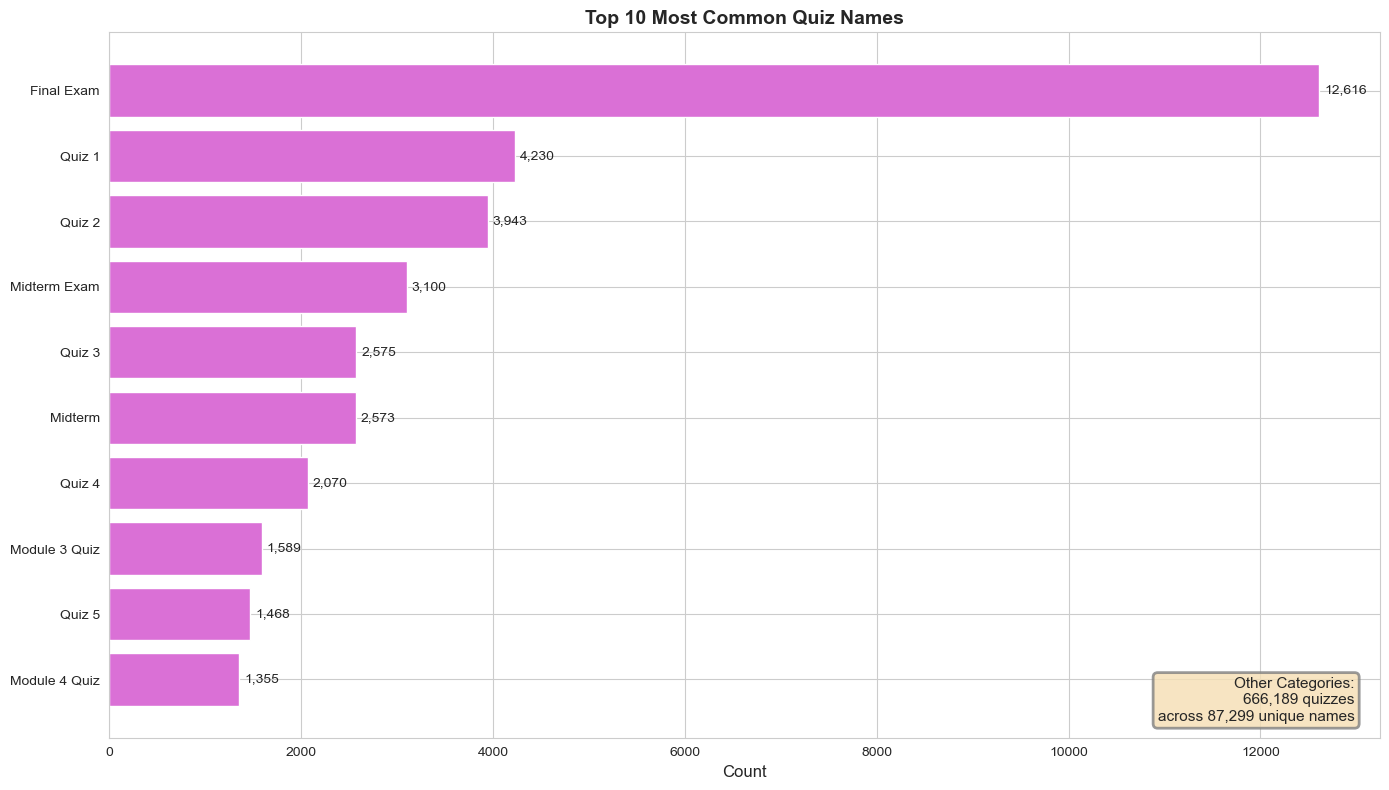

In [8]:
top_10_quiz_names = df_quizzes['quiz_name'].value_counts().head(10)
other_count = df_quizzes['quiz_name'].value_counts().iloc[10:].sum()
unique_other_names = len(df_quizzes['quiz_name'].value_counts().iloc[10:])

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(range(len(top_10_quiz_names)), top_10_quiz_names.values, color='orchid')
ax.set_yticks(range(len(top_10_quiz_names)))
ax.set_yticklabels(top_10_quiz_names.index)
ax.set_xlabel('Count', fontsize=12)
ax.set_title('Top 10 Most Common Quiz Names', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(top_10_quiz_names.values):
    ax.text(v + 50, i, f'{v:,}', va='center')

textstr = f'Other Categories:\n{other_count:,} quizzes\nacross {unique_other_names:,} unique names'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='gray', linewidth=2)
ax.text(0.98, 0.02, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()

## Quiz Name Trends Over Time

### Distribution by Year and Term

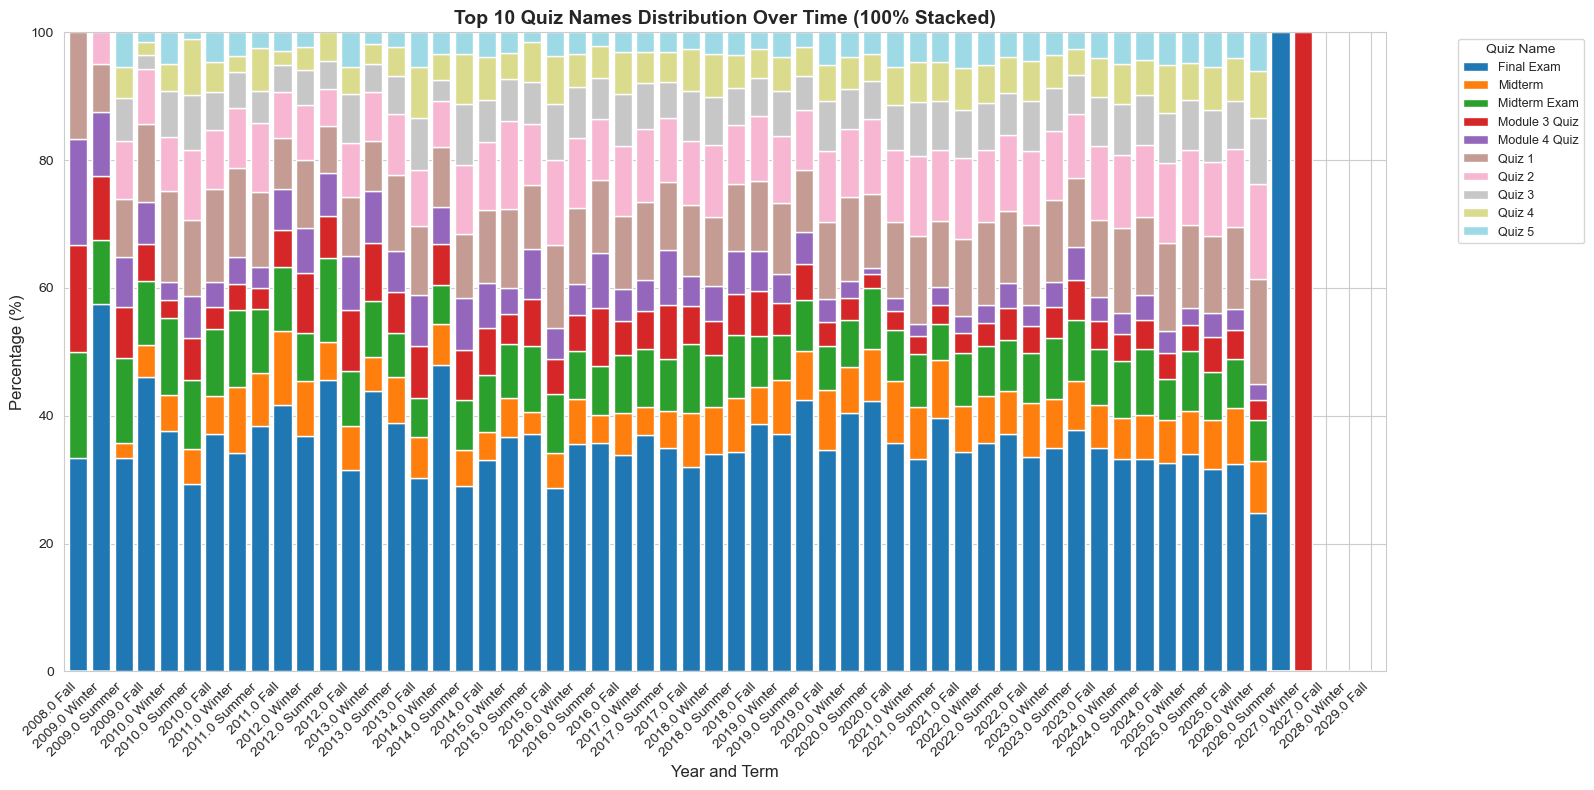


Total quizzes by year-term:
year_term
2008.0 Fall         6.0
2009.0 Winter      40.0
2009.0 Summer     165.0
2009.0 Fall       139.0
2010.0 Winter     141.0
2010.0 Summer      92.0
2010.0 Fall       151.0
2011.0 Winter     193.0
2011.0 Summer     120.0
2011.0 Fall       139.0
2012.0 Winter     255.0
2012.0 Summer     136.0
2012.0 Fall       260.0
2013.0 Winter     319.0
2013.0 Summer     219.0
2013.0 Fall       297.0
2014.0 Winter     296.0
2014.0 Summer     231.0
2014.0 Fall       339.0
2015.0 Winter     463.0
2015.0 Summer     259.0
2015.0 Fall       489.0
2016.0 Winter     483.0
2016.0 Summer     324.0
2016.0 Fall       463.0
2017.0 Winter     541.0
2017.0 Summer     358.0
2017.0 Fall       425.0
2018.0 Winter     589.0
2018.0 Summer     391.0
2018.0 Fall       528.0
2019.0 Winter     693.0
2019.0 Summer     435.0
2019.0 Fall       704.0
2020.0 Winter    1127.0
2020.0 Summer     899.0
2020.0 Fall      1835.0
2021.0 Winter    1838.0
2021.0 Summer    1027.0
2021.0 Fall      1486.0
2

In [5]:
df_quizzes['creation_date_parsed'] = pd.to_datetime(df_quizzes['creation_date'], errors='coerce')
df_quizzes['year'] = df_quizzes['creation_date_parsed'].dt.year
df_quizzes['month'] = df_quizzes['creation_date_parsed'].dt.month

def get_term(month):
    if pd.isna(month):
        return 'Unknown'
    elif month in [1, 2, 3, 4]:
        return 'Winter'
    elif month in [5, 6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_quizzes['term'] = df_quizzes['month'].apply(get_term)
df_quizzes['year_term'] = df_quizzes['year'].astype(str) + ' ' + df_quizzes['term']

top_10_names = df_quizzes['quiz_name'].value_counts().head(10).index.tolist()

df_filtered = df_quizzes[df_quizzes['quiz_name'].isin(top_10_names)].copy()
df_filtered.loc[~df_filtered['quiz_name'].isin(top_10_names), 'quiz_name'] = 'Other'

trend_data = df_filtered.groupby(['year_term', 'quiz_name']).size().unstack(fill_value=0)

year_term_order = df_quizzes[df_quizzes['year_term'] != 'nan Unknown'].groupby('year_term')['creation_date_parsed'].min().sort_values().index.tolist()
trend_data = trend_data.reindex(year_term_order, fill_value=0)

trend_pct = trend_data.div(trend_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 8))
trend_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.8)

ax.set_xlabel('Year and Term', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Top 10 Quiz Names Distribution Over Time (100% Stacked)', fontsize=14, fontweight='bold')
ax.legend(title='Quiz Name', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTotal quizzes by year-term:")
print(df_filtered.groupby('year_term').size().reindex(year_term_order))

### Distribution by 5-Year Intervals

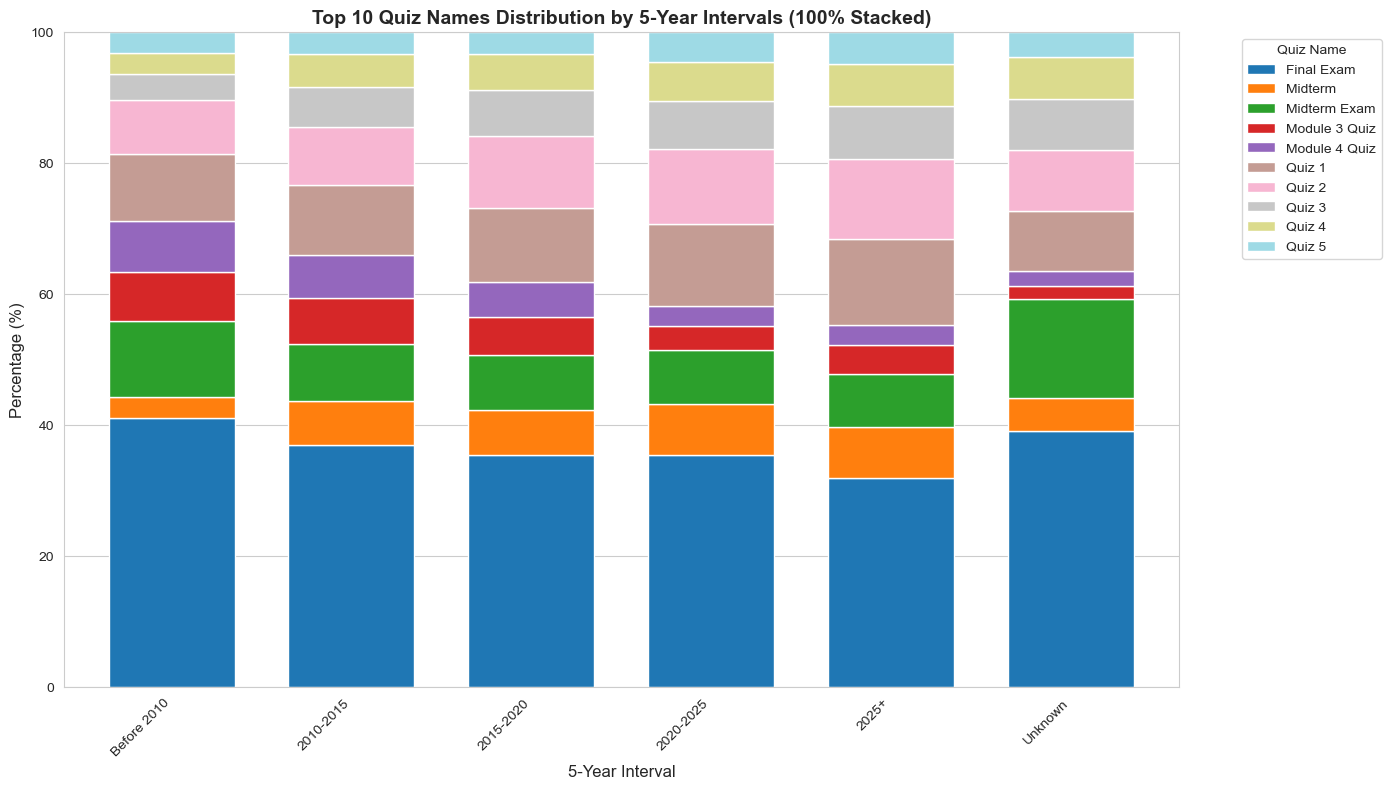


Total quizzes by 5-year interval:
interval
Before 2010      350
2010-2015       3188
2015-2020       7145
2020-2025      18392
2025+           4296
Unknown         2148
dtype: int64


In [6]:
def assign_interval(year):
    if pd.isna(year):
        return 'Unknown'
    elif 2010 <= year < 2015:
        return '2010-2015'
    elif 2015 <= year < 2020:
        return '2015-2020'
    elif 2020 <= year < 2025:
        return '2020-2025'
    elif year >= 2025:
        return '2025+'
    else:
        return 'Before 2010'

df_quizzes['interval'] = df_quizzes['year'].apply(assign_interval)

top_10_names_interval = df_quizzes['quiz_name'].value_counts().head(10).index.tolist()

df_interval_filtered = df_quizzes[df_quizzes['quiz_name'].isin(top_10_names_interval)].copy()

interval_data = df_interval_filtered.groupby(['interval', 'quiz_name']).size().unstack(fill_value=0)

interval_order = ['Before 2010', '2010-2015', '2015-2020', '2020-2025', '2025+', 'Unknown']
interval_data = interval_data.reindex([i for i in interval_order if i in interval_data.index], fill_value=0)

interval_pct = interval_data.div(interval_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 8))
interval_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.7)

ax.set_xlabel('5-Year Interval', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Top 10 Quiz Names Distribution by 5-Year Intervals (100% Stacked)', fontsize=14, fontweight='bold')
ax.legend(title='Quiz Name', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.set_ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTotal quizzes by 5-year interval:")
print(df_interval_filtered.groupby('interval').size().reindex([i for i in interval_order if i in df_interval_filtered['interval'].unique()]))

## Quiz-Grade Object Linkage

Quizzes with Grade Object ID: 274,534 (39.1%)
Quizzes without Grade Object ID: 427,174 (60.9%)


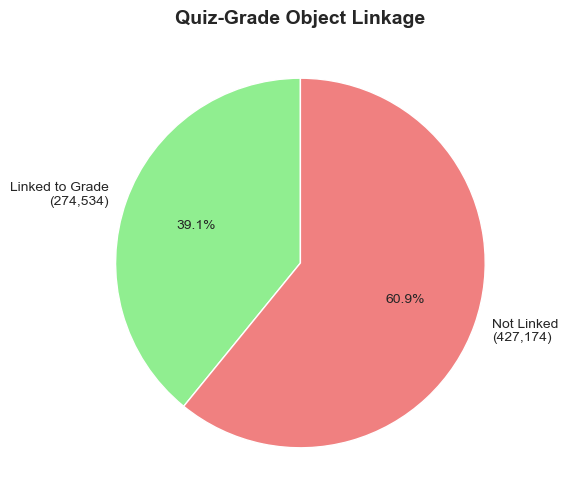

In [7]:
quizzes_with_grade = df_quizzes[df_quizzes['grade_object_id'].notna()]
quizzes_without_grade = df_quizzes[df_quizzes['grade_object_id'].isna()]

print(f"Quizzes with Grade Object ID: {len(quizzes_with_grade):,} ({len(quizzes_with_grade)/len(df_quizzes)*100:.1f}%)")
print(f"Quizzes without Grade Object ID: {len(quizzes_without_grade):,} ({len(quizzes_without_grade)/len(df_quizzes)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 6))
linkage_data = [len(quizzes_with_grade), len(quizzes_without_grade)]
linkage_labels = [f'Linked to Grade\n({len(quizzes_with_grade):,})', f'Not Linked\n({len(quizzes_without_grade):,})']
colors = ['lightgreen', 'lightcoral']
ax.pie(linkage_data, labels=linkage_labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Quiz-Grade Object Linkage', fontsize=14, fontweight='bold')
plt.show()

### Courses Using Both Quizzes and Grade Objects Without Linking

In [8]:
# Identify courses that have both quizzes and grade objects
courses_with_quizzes = set(df_quizzes['org_unit_id'].unique())
courses_with_grades = set(df_grades['org_unit_id'].unique())

# Courses with both quizzes and grade objects
courses_with_both = courses_with_quizzes & courses_with_grades

print(f"Total courses with quizzes: {len(courses_with_quizzes):,}")
print(f"Total courses with grade objects: {len(courses_with_grades):,}")
print(f"Courses with both quizzes and grade objects: {len(courses_with_both):,}")

# For courses with both, check if any quizzes are linked to grade objects
courses_with_linkage = set()
for course_id in courses_with_both:
    course_quizzes = df_quizzes[df_quizzes['org_unit_id'] == course_id]
    if course_quizzes['grade_object_id'].notna().any():
        courses_with_linkage.add(course_id)

courses_with_both_but_no_linkage = courses_with_both - courses_with_linkage

print(f"\nCourses with linked quizzes: {len(courses_with_linkage):,}")
print(f"Courses with both but NO linkage: {len(courses_with_both_but_no_linkage):,}")
print(f"Percentage of courses with both that don't link: {len(courses_with_both_but_no_linkage)/len(courses_with_both)*100:.1f}%")

Total courses with quizzes: 59,416
Total courses with grade objects: 189,169
Courses with both quizzes and grade objects: 59,352

Courses with linked quizzes: 41,275
Courses with both but NO linkage: 18,077
Percentage of courses with both that don't link: 30.5%


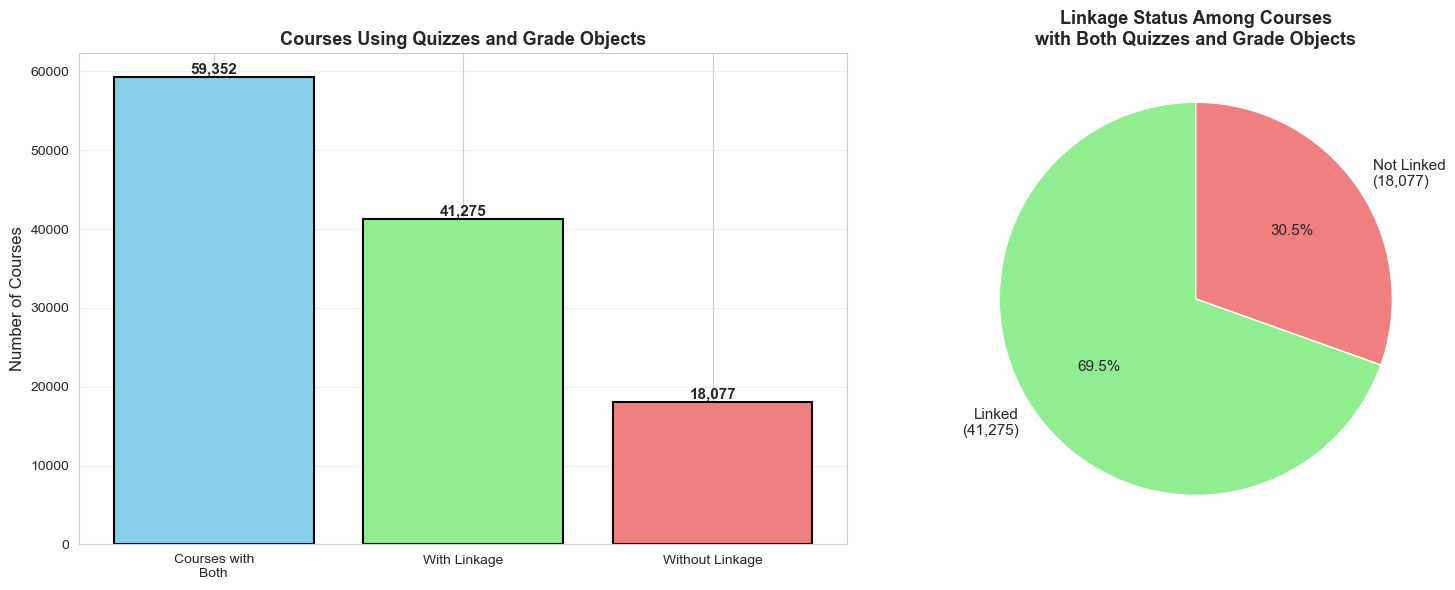


KEY INSIGHT:
Out of 59,352 courses that have BOTH quizzes and grade objects,
18,077 courses (30.5%) are NOT linking them together.


In [9]:
# Visualize the breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Overall course breakdown
categories = ['Courses with\nBoth', 'With Linkage', 'Without Linkage']
values = [len(courses_with_both), len(courses_with_linkage), len(courses_with_both_but_no_linkage)]
colors_chart1 = ['skyblue', 'lightgreen', 'lightcoral']

bars1 = ax1.bar(categories, values, color=colors_chart1, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Number of Courses', fontsize=12)
ax1.set_title('Courses Using Quizzes and Grade Objects', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Chart 2: Pie chart of linkage status among courses with both
linkage_status = [len(courses_with_linkage), len(courses_with_both_but_no_linkage)]
linkage_labels = [f'Linked\n({len(courses_with_linkage):,})', 
                  f'Not Linked\n({len(courses_with_both_but_no_linkage):,})']
colors_chart2 = ['lightgreen', 'lightcoral']

ax2.pie(linkage_status, labels=linkage_labels, autopct='%1.1f%%', 
        colors=colors_chart2, startangle=90, textprops={'fontsize': 11})
ax2.set_title('Linkage Status Among Courses\nwith Both Quizzes and Grade Objects', 
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Additional statistics
print(f"\n{'='*60}")
print("KEY INSIGHT:")
print(f"{'='*60}")
print(f"Out of {len(courses_with_both):,} courses that have BOTH quizzes and grade objects,")
print(f"{len(courses_with_both_but_no_linkage):,} courses ({len(courses_with_both_but_no_linkage)/len(courses_with_both)*100:.1f}%) are NOT linking them together.")
print(f"{'='*60}")

### Temporal Analysis: Quiz-Grade Linkage Over Time

In [11]:
# Create time period bins for temporal analysis
def assign_time_period(year):
    if pd.isna(year):
        return 'Unknown'
    elif 2010 <= year <= 2015:
        return '2010-2015'
    elif 2016 <= year <= 2020:
        return '2016-2020'
    elif 2021 <= year <= 2025:
        return '2021-2025'
    else:
        return 'Other'

df_quizzes['time_period'] = df_quizzes['year'].apply(assign_time_period)

# Calculate linkage statistics by time period
time_periods = ['2010-2015', '2016-2020', '2021-2025']
linkage_by_period = []

for period in time_periods:
    period_quizzes = df_quizzes[df_quizzes['time_period'] == period]
    total_quizzes = len(period_quizzes)
    linked_quizzes = len(period_quizzes[period_quizzes['grade_object_id'].notna()])
    unlinked_quizzes = total_quizzes - linked_quizzes
    
    linkage_by_period.append({
        'Period': period,
        'Linked': linked_quizzes,
        'Not Linked': unlinked_quizzes,
        'Total': total_quizzes,
        'Linked %': (linked_quizzes / total_quizzes * 100) if total_quizzes > 0 else 0
    })

linkage_df = pd.DataFrame(linkage_by_period)
print("Quiz-Grade Object Linkage by Time Period:")
print(linkage_df.to_string(index=False))
print()

Quiz-Grade Object Linkage by Time Period:
   Period  Linked  Not Linked  Total  Linked %
2010-2015   31334       86610 117944 26.566845
2016-2020   76938      121116 198054 38.846981
2021-2025  140069      191258 331327 42.275154



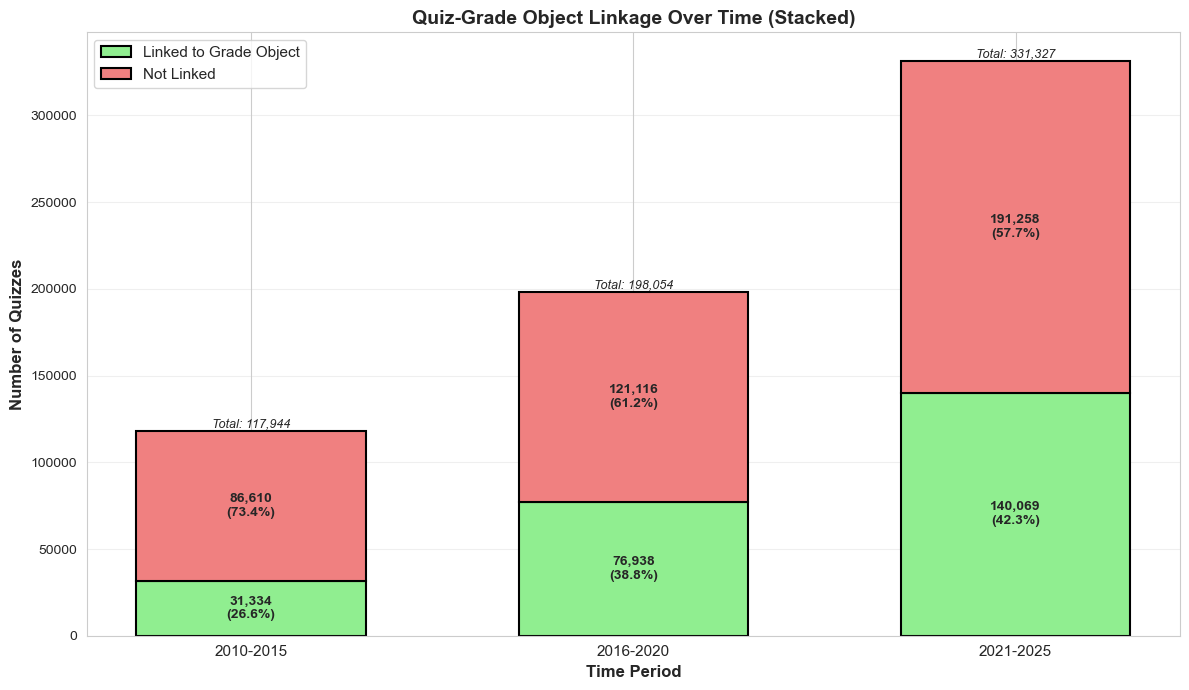


TEMPORAL TRENDS:
2010-2015: 26.6% linked (31,334 of 117,944 quizzes)
2016-2020: 38.8% linked (76,938 of 198,054 quizzes)
2021-2025: 42.3% linked (140,069 of 331,327 quizzes)


In [12]:
# Create stacked bar chart showing temporal changes
fig, ax = plt.subplots(figsize=(12, 7))

periods = linkage_df['Period'].tolist()
linked = linkage_df['Linked'].tolist()
not_linked = linkage_df['Not Linked'].tolist()

x = np.arange(len(periods))
width = 0.6

# Create stacked bars
bars1 = ax.bar(x, linked, width, label='Linked to Grade Object', color='lightgreen', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x, not_linked, width, bottom=linked, label='Not Linked', color='lightcoral', edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (p1, p2) in enumerate(zip(linked, not_linked)):
    # Linked section
    ax.text(i, p1/2, f'{p1:,}\n({linkage_df.iloc[i]["Linked %"]:.1f}%)', 
            ha='center', va='center', fontsize=10, fontweight='bold')
    # Not linked section
    ax.text(i, p1 + p2/2, f'{p2:,}\n({100-linkage_df.iloc[i]["Linked %"]:.1f}%)', 
            ha='center', va='center', fontsize=10, fontweight='bold')
    # Total on top
    ax.text(i, p1 + p2, f'Total: {p1+p2:,}', 
            ha='center', va='bottom', fontsize=9, style='italic')

ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Quizzes', fontsize=12, fontweight='bold')
ax.set_title('Quiz-Grade Object Linkage Over Time (Stacked)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods, fontsize=11)
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary insights
print("\n" + "="*70)
print("TEMPORAL TRENDS:")
print("="*70)
for _, row in linkage_df.iterrows():
    print(f"{row['Period']}: {row['Linked %']:.1f}% linked ({row['Linked']:,} of {row['Total']:,} quizzes)")
print("="*70)